In [13]:
# 1. Load the CSVs
weather_df = pd.read_csv('../backend/data/historical_weather_magdeburg.csv')
occ_df = pd.read_csv('../backend/data/synthetic_occupancy_data.csv')

# 🛠️ THE FIX: Force both time columns to be perfectly identical before merging
weather_df['time'] = pd.to_datetime(weather_df['time'], format='mixed').dt.tz_localize(None).dt.floor('h')
occ_df['time'] = pd.to_datetime(occ_df['time'], format='mixed').dt.tz_localize(None).dt.floor('h')

# 2. Merge on time
df = pd.merge(weather_df, occ_df, on='time', how='inner')

# 🚨 Safety Check: Make sure the merge actually worked!
print(f"Data merged! We have {len(df)} overlapping hours of data.")
if len(df) < 100:
    print("⚠️ WARNING: The merge failed. Check your CSV date ranges!")

# 3. Synthesize the Target Variable (Energy Consumption in Watts)
base_load = 250 
occupancy_load = (df['occ_living_room'] * 300) + (df['occ_kitchen'] * 500) + (df['occ_master_bed'] * 150)

hvac_load = np.where(df['temperature_2m'] > 24, (df['temperature_2m'] - 24) * 150, 0)
hvac_load += np.where(df['temperature_2m'] < 18, (18 - df['temperature_2m']) * 120, 0)

df['energy_watts'] = base_load + occupancy_load + hvac_load + np.random.normal(0, 50, len(df))
df['energy_watts'] = df['energy_watts'].clip(lower=100) 

df.head()

Data merged! We have 2161 overlapping hours of data.


,time,temperature_2m,relative_humidity_2m,direct_radiation,cloud_cover,hour,day_of_week,is_weekend,occ_living_room,occ_kitchen,occ_master_bed,energy_watts
0,2026-02-09 15:00:00,0.9,89,10.0,100,15,0,0,1,0,0,2449.036927
1,2026-02-09 16:00:00,1.0,88,0.0,100,16,0,0,0,0,0,2255.780460
2,2026-02-09 17:00:00,1.2,89,0.0,100,17,0,0,1,0,1,2727.181170
3,2026-02-09 18:00:00,1.0,90,0.0,100,18,0,0,1,1,0,3129.218593
4,2026-02-09 19:00:00,0.9,91,0.0,100,19,0,0,1,1,0,3078.098243


📉 Model Accuracy Metrics:
MAPE (Mean Absolute Percentage Error): 24.83%
RMSE (Root Mean Squared Error): 298.13 Watts


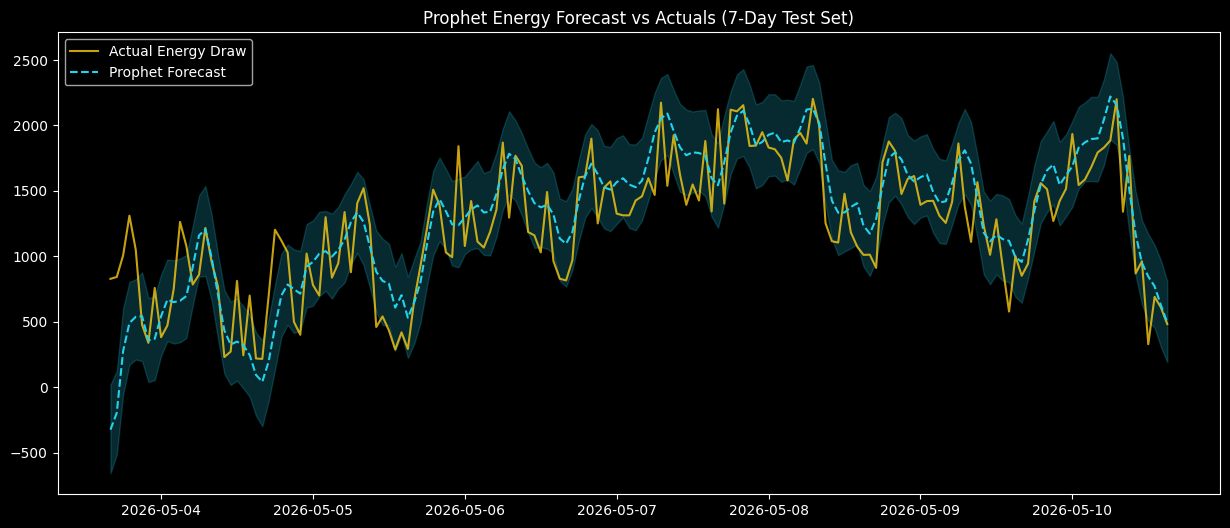

In [14]:
# Make predictions on the test set
forecast = model.predict(test_df.drop(columns=['y']))

# Calculate accuracy metrics
mape = mean_absolute_percentage_error(test_df['y'], forecast['yhat']) * 100
rmse = np.sqrt(mean_squared_error(test_df['y'], forecast['yhat']))

print(f"📉 Model Accuracy Metrics:")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} Watts")

# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(test_df['ds'], test_df['y'], label='Actual Energy Draw', color='#facc15', alpha=0.8)
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', color='#22d3ee', linestyle='--')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='#22d3ee', alpha=0.2)
plt.title('Prophet Energy Forecast vs Actuals (7-Day Test Set)')
plt.legend()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import joblib
import os

# Ensure the model_store directory exists
os.makedirs("../backend/model_store", exist_ok=True)
plt.style.use('dark_background') # Because we love dark mode UIs!

In [16]:
# Save the trained model to the backend store
model_path = "../backend/model_store/prophet_energy_v1.pkl"
joblib.dump(model, model_path)

print(f"✅ Model successfully serialized and saved to: {model_path}")
print("Your FastAPI backend is now ready to serve real AI predictions!")

✅ Model successfully serialized and saved to: ../backend/model_store/prophet_energy_v1.pkl
Your FastAPI backend is now ready to serve real AI predictions!


In [17]:
# Format for Prophet
prophet_df = df[['time', 'energy_watts', 'temperature_2m', 'cloud_cover', 'is_weekend']].copy()
prophet_df.rename(columns={'time': 'ds', 'energy_watts': 'y'}, inplace=True)

# Split into Train (first 83 days) and Test (last 7 days)
train_size = len(prophet_df) - (7 * 24)
train_df = prophet_df.iloc[:train_size]
test_df = prophet_df.iloc[train_size:]

print(f"Training on {len(train_df)} hours, Testing on {len(test_df)} hours.")

Training on 1993 hours, Testing on 168 hours.


In [18]:
# Initialize Prophet with explicit seasonalities
model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True)

# Add external regressors (things that influence power draw besides just the time of day)
model.add_regressor('temperature_2m')
model.add_regressor('is_weekend')

# Train the model!
print("Training Prophet model (this might take a few seconds)...")
model.fit(train_df)
print("Training complete!")

Training Prophet model (this might take a few seconds)...


16:24:16 - cmdstanpy - INFO - Chain [1] start processing
16:24:17 - cmdstanpy - INFO - Chain [1] done processing


Training complete!
